In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import cv2
import pandas as pd
import shutil
from tqdm import tqdm

In [3]:
CSV_PATH = "/kaggle/input/datasets/daluanjali/vinbig-ass/Data/train.csv"
IMAGE_PATH = "/kaggle/input/datasets/daluanjali/vinbig-ass/images/train"

WORK_DIR = "/kaggle/working/vinbig"

TRAIN_IMG = f"{WORK_DIR}/images/train"
VAL_IMG = f"{WORK_DIR}/images/val"

TRAIN_LABEL = f"{WORK_DIR}/labels/train"
VAL_LABEL = f"{WORK_DIR}/labels/val"

os.makedirs(TRAIN_IMG, exist_ok=True)
os.makedirs(VAL_IMG, exist_ok=True)
os.makedirs(TRAIN_LABEL, exist_ok=True)
os.makedirs(VAL_LABEL, exist_ok=True)

In [4]:
df = pd.read_csv(CSV_PATH)

In [5]:
# remove "No finding"
df = df[df["class_id"] != 14]


def create_labels(image_ids, label_dir, img_dir):

    for image_id in tqdm(image_ids):

        img_path = f"{IMAGE_PATH}/{image_id}.jpg"

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        rows = df[df["image_id"] == image_id]

        labels = []

        for _, r in rows.iterrows():

            cls = int(r["class_id"])

            x_min = r["x_min"]
            y_min = r["y_min"]
            x_max = r["x_max"]
            y_max = r["y_max"]

            if pd.isna(x_min):
                continue

            if x_max <= x_min or y_max <= y_min:
                continue

            # correct normalization
            x_center = ((x_min + x_max) / 2) / w
            y_center = ((y_min + y_max) / 2) / h
            width = (x_max - x_min) / w
            height = (y_max - y_min) / h

            # clip values to valid range
            x_center = max(0, min(1, x_center))
            y_center = max(0, min(1, y_center))
            width = max(1e-6, min(1, width))
            height = max(1e-6, min(1, height))

            labels.append(
                f"{cls} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
            )

        label_path = f"{label_dir}/{image_id}.txt"

        with open(label_path, "w") as f:
            f.write("\n".join(labels))

        shutil.copy(img_path, img_dir)

In [6]:
from sklearn.model_selection import train_test_split

image_ids = df["image_id"].unique()

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.1,
    random_state=42
)

create_labels(train_ids, TRAIN_LABEL, TRAIN_IMG)
create_labels(val_ids, VAL_LABEL, VAL_IMG)

100%|██████████| 440/440 [00:06<00:00, 69.57it/s]


In [7]:
# !head /kaggle/working/vinbig/labels/train/*.txt

In [8]:
WORK_DIR = "/kaggle/working/vinbig"

yaml_content = """
path: /kaggle/working/vinbig

train: images/train
val: images/val

names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis
"""

with open(f"{WORK_DIR}/vinbig.yaml", "w") as f:
    f.write(yaml_content)

print("vinbig.yaml created successfully")

vinbig.yaml created successfully


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="/kaggle/working/vinbig/vinbig.yaml",
    epochs=15,
    imgsz=1024,
    batch=8,
    device=0,
    workers=4,
    verbose=False
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/vinbig/vinbig.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bbd5413ce00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [10]:
metrics = model.val(
    data="/kaggle/working/vinbig/vinbig.yaml",
    split="val",
    imgsz=1024,
    batch=8,
    device=0,
    verbose=False
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,847,866 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 967.7±241.9 MB/s, size: 28.5 KB)
val: Scanning /kaggle/working/vinbig/labels/val.cache... 440 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 440/440 205.1Mit/s 0.0s
val: /kaggle/working/vinbig/images/val/0046f681f078851293c4e710c4466058.jpg: 4 duplicate labels removed
val: /kaggle/working/vinbig/images/val/0108949daa13dc94634a7d650a05c0bb.jpg: 2 duplicate labels removed
val: /kaggle/working/vinbig/images/val/010a3dbb67bc37800a041866844861b1.jpg: 3 duplicate labels removed
val: /kaggle/working/vinbig/images/val/01fec681f2d698497151a88d6c5205a1.jpg: 2 duplicate labels removed
val: /kaggle/working/vinbig/images/val/025534801b62d61f1c1c9e571ea74695.jpg: 3 duplicate labels removed
val: /kaggle/working/vinbig/images/val/02d9d0c89022adc381c23e72add7c389.jpg: 1 duplicate labels 

<h1>Evaluation</h1>

In [11]:
print("Evaluation Results")
print("-------------------")

print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Evaluation Results
-------------------
Precision: 0.0000
Recall: 0.0059
mAP50: 0.0000
mAP50-95: 0.0000


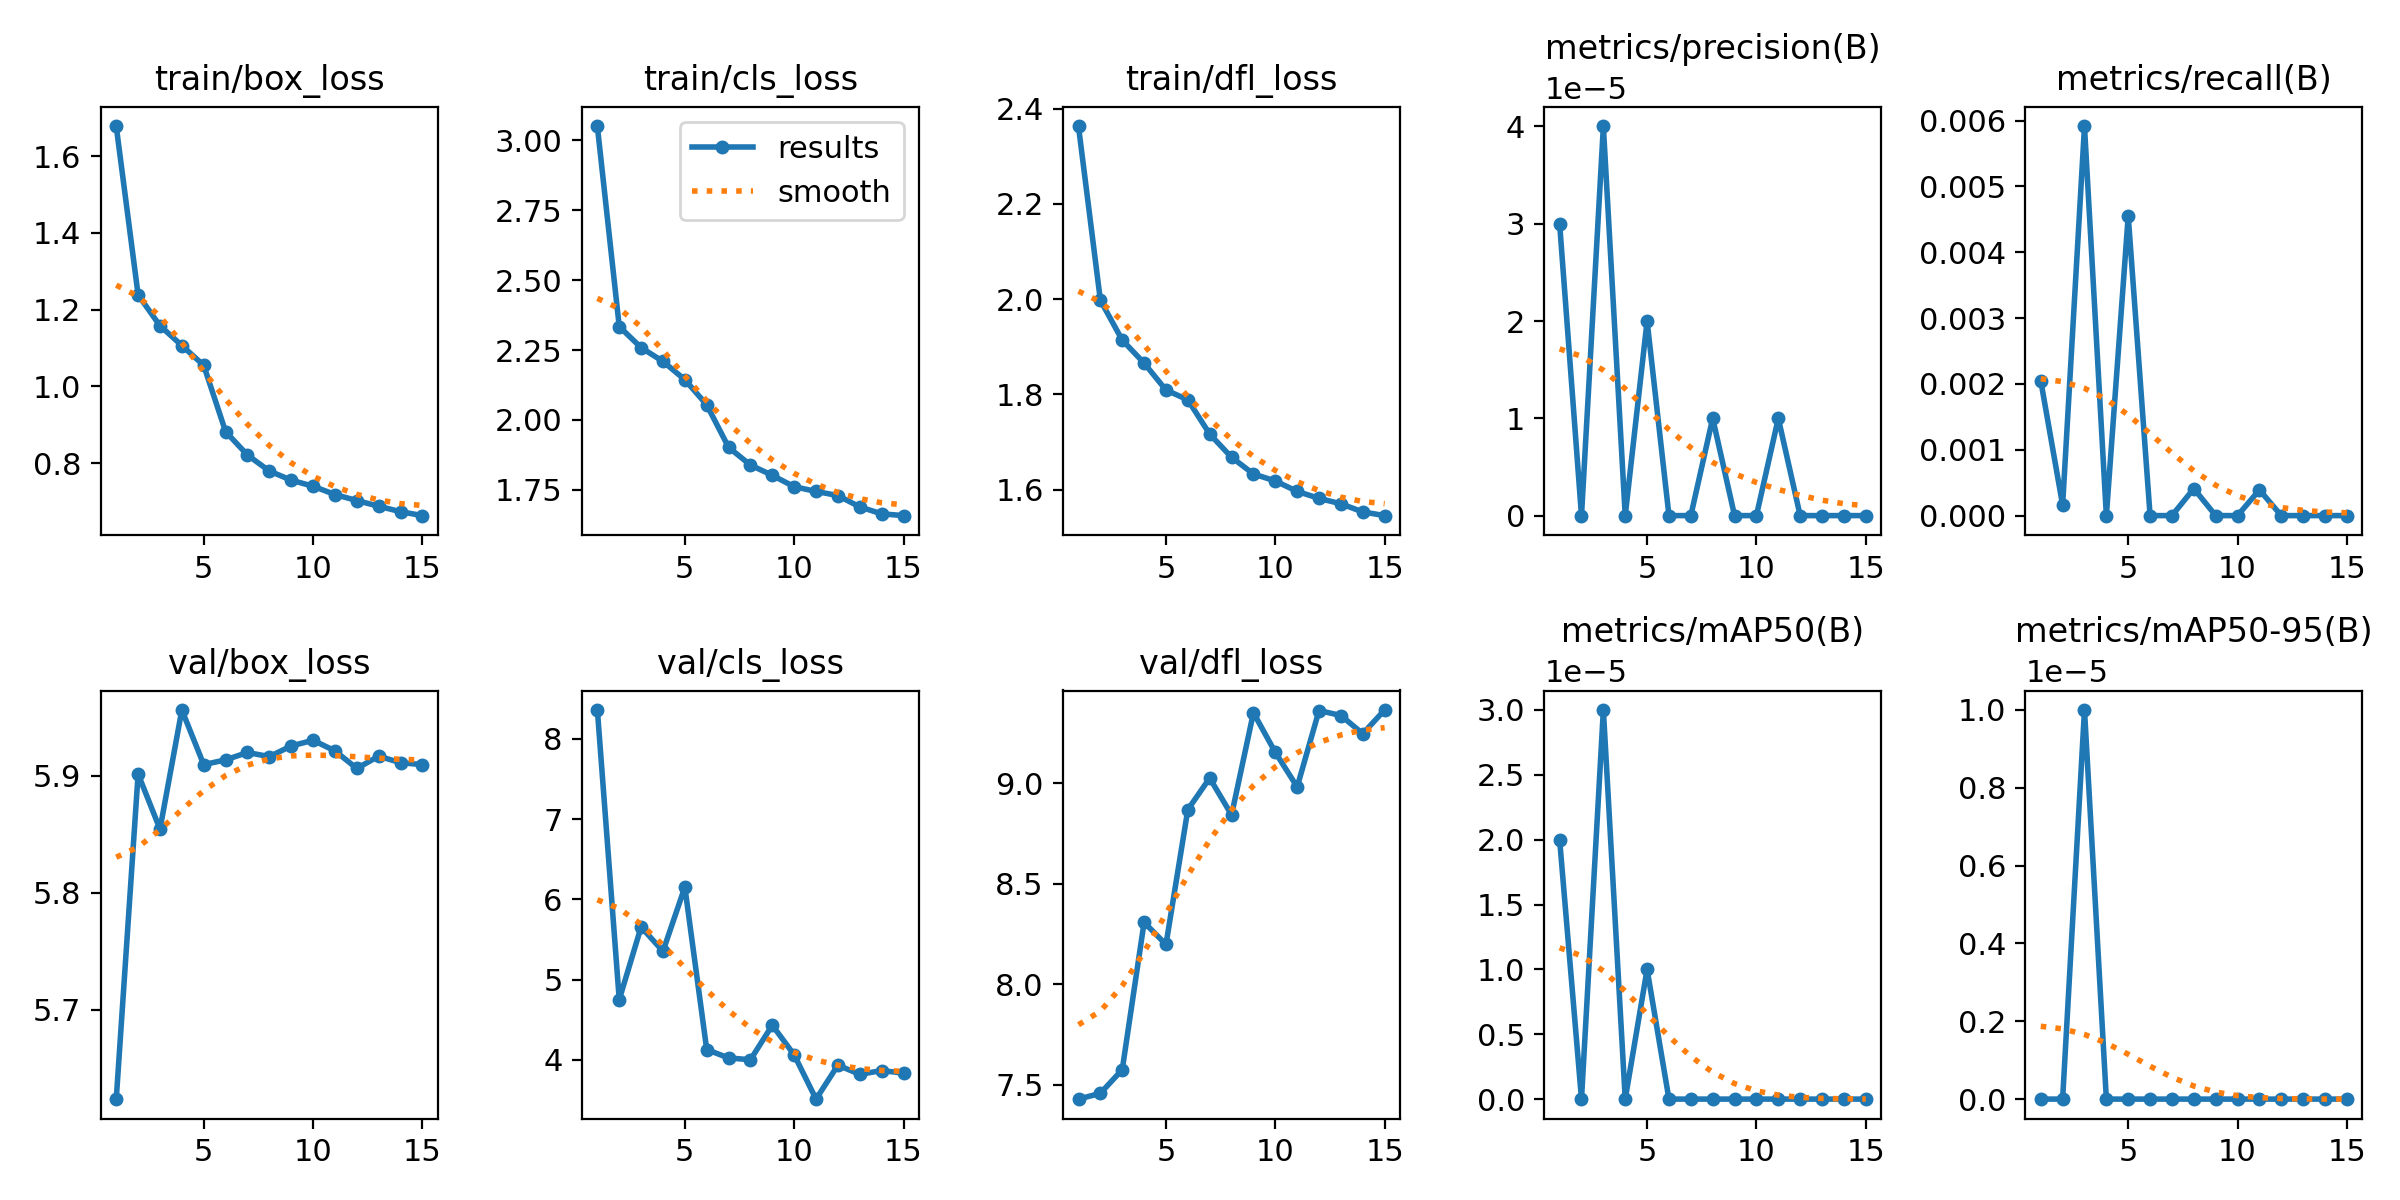

In [ ]:
from IPython.display import Image, display

display(Image("/kaggle/working/runs/detect/train/results.png"))
